# 03 — Transfer Learning (EfficientNet-B0)

**Brain Tumor Detection** — Model 2 of 3.

Two-stage training of an ImageNet-pretrained EfficientNet-B0:

1. **Stage 1 (warmup)** — freeze the backbone, train only the new 4-class head for 4 epochs at LR 1e-3.
2. **Stage 2 (fine-tune)** — unfreeze everything and fine-tune for 8 epochs at LR 1e-4.

Outputs:
* `models/transfer_model.pth`                            — best checkpoint by val_acc
* `outputs/reports/transfer_stage{1,2}_history.json`     — per-stage metrics
* `outputs/plots/transfer_training_curves.png`           — combined 2-stage curve
* `outputs/confusion_matrices/transfer_val_cm.png`
* `logs/transfer_stage1/`, `logs/transfer_stage2/`       — TensorBoard events

In [1]:
# --- 0. Setup ---------------------------------------------------------
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src' / '__init__.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from src.config import (
    CLASS_NAMES, NUM_CLASSES, BATCH_SIZE, NUM_WORKERS,
    OUTPUTS_DIR, MODELS_DIR, LOGS_DIR,
)
from src.data_loader     import get_dataloaders
from src.transfer_model  import build_transfer_model
from src.train           import fit, evaluate, TrainHistory
from src.evaluate        import (
    logits_to_preds, build_classification_report,
    plot_confusion_matrix, per_class_metrics_df,
)
from src.utils           import get_device, set_seed

set_seed(42)
device = get_device()
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
GPU    : NVIDIA GeForce GTX 1650


## 1. DataLoaders

Same loaders as STEP 7 — stratified 80/20 train/val and held-out test.

In [2]:
train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
)
print(f'Train batches: {len(train_loader)}  ({len(train_loader.dataset)} images)')
print(f'Val   batches: {len(val_loader)}    ({len(val_loader.dataset)} images)')

Train batches: 140  (4480 images)
Val   batches: 35    (1120 images)


## 2. Build the model (Stage 1: frozen backbone)

Only the new classifier head (`Linear(1280, 4)`) will have gradients.

In [3]:
model = build_transfer_model(
    backbone        = 'efficientnet_b0',
    num_classes     = NUM_CLASSES,
    pretrained      = True,
    freeze_backbone = True,
    dropout         = 0.3,
)
print(f'Backbone        : {model.backbone_name}')
print(f'Feature dim     : {model.feature_dim}')
print(f'Total params    : {model.num_total_parameters():,}')
print(f'Stage 1 trainable: {model.num_trainable_parameters():,}  (head only)')

Backbone        : efficientnet_b0
Feature dim     : 1280
Total params    : 4,012,672
Stage 1 trainable: 5,124  (head only)


## 3. Stage 1 — Warmup (frozen backbone, head only)

4 epochs at LR=1e-3. We expect val accuracy to climb to ~90 % within the
first 2 epochs because the pretrained features are already excellent;
only the head needs to learn the 4-way mapping.

In [4]:
model, history_s1, best_acc_s1 = fit(
    model         = model,
    train_loader  = train_loader,
    val_loader    = val_loader,
    epochs        = 4,
    lr            = 1e-3,        # higher LR -- only the head is learning
    weight_decay  = 1e-4,
    patience      = 10,          # don't early-stop in stage 1; we want all 4 epochs
    use_amp       = (device.type == 'cuda'),
    amp_dtype     = torch.bfloat16,
    run_name      = 'transfer_stage1',
    checkpoint_path = MODELS_DIR / 'transfer_model.pth',
    log_dir         = LOGS_DIR    / 'transfer_stage1',
    history_path    = OUTPUTS_DIR / 'reports' / 'transfer_stage1_history.json',
    seed          = 42,
)

[fit] run_name        = transfer_stage1
[fit] device          = cuda
[fit] trainable params = 5,124
[fit] train batches    = 140 | val batches = 35
[fit] lr=1e-03  wd=1e-04  amp=True(torch.bfloat16)  epochs=4  patience=10
[fit] checkpoint -> C:\Brain Tumor Detection\models\transfer_model.pth
[fit] tensorboard -> C:\Brain Tumor Detection\logs\transfer_stage1



E01/4 train:   0%|          | 0/140 [00:15<?, ?it/s]

E01/4 val:   0%|          | 0/35 [00:35<?, ?it/s]

Epoch 01/4  train_loss=0.7099 train_acc=0.7243  |  val_loss=0.5119 val_acc=0.7973  lr=8.55e-04  time=80.5s  <- best


E02/4 train:   0%|          | 0/140 [00:00<?, ?it/s]

...

E03/4 val:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 03/4  train_loss=0.4063 train_acc=0.8502  |  val_loss=0.3561 val_acc=0.8839  lr=1.55e-04  time=24.9s  <- best


E04/4 train:   0%|          | 0/140 [00:00<?, ?it/s]

E04/4 val:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 04/4  train_loss=0.3816 train_acc=0.8587  |  val_loss=0.3536 val_acc=0.8804  lr=1.00e-05  time=24.8s

[fit] Done in 2.6 min
[fit] Best val_acc = 0.8839 (epoch 3)
[fit] Best val_loss= 0.3561
[fit] Checkpoint saved -> C:\Brain Tumor Detection\models\transfer_model.pth
[fit] History saved    -> C:\Brain Tumor Detection\outputs\reports\transfer_stage1_history.json


## 4. Unfreeze the backbone (transition to Stage 2)

In [5]:
model.unfreeze_backbone()
print(f'Stage 2 trainable: {model.num_trainable_parameters():,}  (entire model)')

Stage 2 trainable: 4,012,672  (entire model)


## 5. Stage 2 — Fine-tune the whole network

8 epochs at LR=1e-4 (**10× smaller** than stage 1). This is the key
transfer-learning hyperparameter — a low LR delicately adapts the
pretrained backbone without destroying it.

In [6]:
model, history_s2, best_acc_s2 = fit(
    model         = model,
    train_loader  = train_loader,
    val_loader    = val_loader,
    epochs        = 8,
    lr            = 1e-4,        # 10x smaller -- protects pretrained weights
    weight_decay  = 1e-4,
    patience      = 5,
    use_amp       = (device.type == 'cuda'),
    amp_dtype     = torch.bfloat16,
    run_name      = 'transfer_stage2',
    checkpoint_path = MODELS_DIR / 'transfer_model.pth',     # overwrites stage 1 ckpt if better
    log_dir         = LOGS_DIR    / 'transfer_stage2',
    history_path    = OUTPUTS_DIR / 'reports' / 'transfer_stage2_history.json',
    seed          = 42,
)

best_val_acc = max(best_acc_s1, best_acc_s2)
print(f'\nBest val_acc (Stage 1) : {best_acc_s1:.4f}')
print(f'Best val_acc (Stage 2) : {best_acc_s2:.4f}')
print(f'Overall best val_acc   : {best_val_acc:.4f}')

[fit] run_name        = transfer_stage2
[fit] device          = cuda
[fit] trainable params = 4,012,672
[fit] train batches    = 140 | val batches = 35
[fit] lr=1e-04  wd=1e-04  amp=True(torch.bfloat16)  epochs=8  patience=5
[fit] checkpoint -> C:\Brain Tumor Detection\models\transfer_model.pth
[fit] tensorboard -> C:\Brain Tumor Detection\logs\transfer_stage2



E01/8 train:   0%|          | 0/140 [00:00<?, ?it/s]

E01/8 val:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 01/8  train_loss=0.4069 train_acc=0.8536  |  val_loss=0.2072 val_acc=0.9330  lr=9.62e-05  time=87.6s  <- best


E02/8 train:   0%|          | 0/140 [00:00<?, ?it/s]

...

E07/8 val:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 07/8  train_loss=0.0681 train_acc=0.9748  |  val_loss=0.0362 val_acc=0.9893  lr=4.77e-06  time=100.5s  <- best


E08/8 train:   0%|          | 0/140 [00:00<?, ?it/s]

E08/8 val:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 08/8  train_loss=0.0601 train_acc=0.9810  |  val_loss=0.0357 val_acc=0.9875  lr=1.00e-06  time=100.2s

[fit] Done in 12.3 min
[fit] Best val_acc = 0.9893 (epoch 7)
[fit] Best val_loss= 0.0362
[fit] Checkpoint saved -> C:\Brain Tumor Detection\models\transfer_model.pth
[fit] History saved    -> C:\Brain Tumor Detection\outputs\reports\transfer_stage2_history.json

Best val_acc (Stage 1) : 0.8839
Best val_acc (Stage 2) : 0.9893
Overall best val_acc   : 0.9893


## 6. Combined training curves

Stage 1 and Stage 2 plotted on one timeline, with a vertical separator.
Look for: a clear *jump* at the unfreeze point as the backbone starts
fine-tuning, then continued improvement.

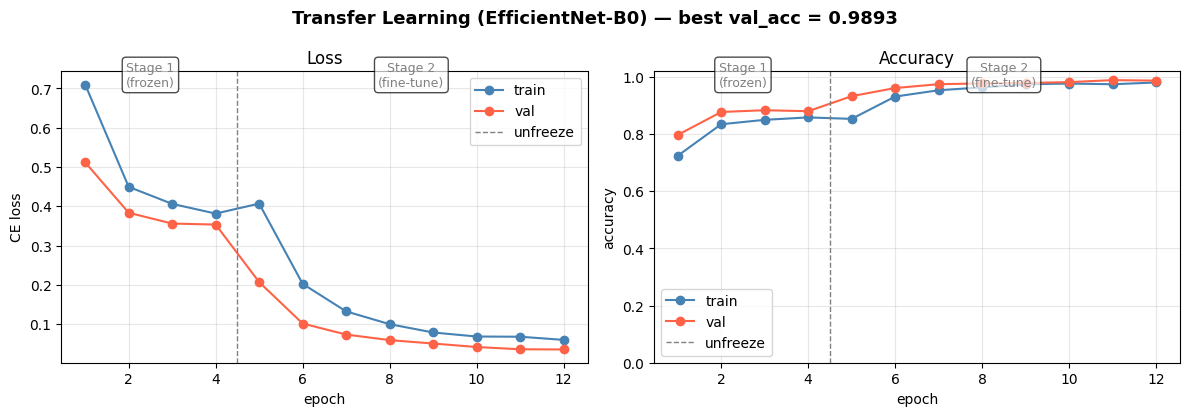

In [7]:
n1 = len(history_s1.train_loss)
n2 = len(history_s2.train_loss)
total_epochs = n1 + n2
epochs = np.arange(1, total_epochs + 1)

train_loss = history_s1.train_loss + history_s2.train_loss
val_loss   = history_s1.val_loss   + history_s2.val_loss
train_acc  = history_s1.train_acc  + history_s2.train_acc
val_acc    = history_s1.val_acc    + history_s2.val_acc

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(epochs, train_loss, '-o', label='train', color='steelblue')
axes[0].plot(epochs, val_loss,   '-o', label='val',   color='tomato')
axes[0].axvline(n1 + 0.5, color='gray', ls='--', lw=1, label='unfreeze')
axes[0].set_title('Loss');  axes[0].set_xlabel('epoch'); axes[0].set_ylabel('CE loss')
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(epochs, train_acc, '-o', label='train', color='steelblue')
axes[1].plot(epochs, val_acc,   '-o', label='val',   color='tomato')
axes[1].axvline(n1 + 0.5, color='gray', ls='--', lw=1, label='unfreeze')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0, 1.02); axes[1].grid(alpha=0.3); axes[1].legend()

# Annotate stage regions
for ax in axes:
    ax.text(n1 / 2 + 0.5, ax.get_ylim()[1] * 0.95,
            f'Stage 1\n(frozen)', ha='center', fontsize=9,
            color='gray', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    ax.text(n1 + n2 / 2 + 0.5, ax.get_ylim()[1] * 0.95,
            f'Stage 2\n(fine-tune)', ha='center', fontsize=9,
            color='gray', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

fig.suptitle(
    f'Transfer Learning (EfficientNet-B0) — best val_acc = {best_val_acc:.4f}',
    fontsize=13, fontweight='bold',
)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'plots' / 'transfer_training_curves.png',
            dpi=120, bbox_inches='tight')
plt.show()

## 7. Validation evaluation — confusion matrix

Uses the best checkpoint (already loaded into `model` by the second `fit()` call).

final val:   0%|          | 0/35 [00:00<?, ?it/s]

Final val loss: 0.0362
Final val acc : 0.9893


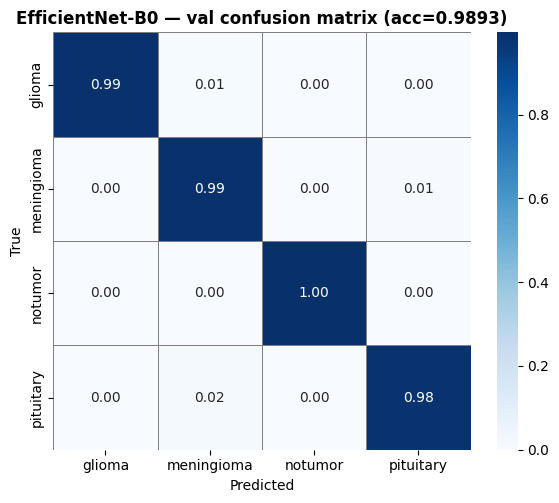

In [8]:
val_loss, val_acc, val_logits, val_labels = evaluate(
    model, val_loader, nn.CrossEntropyLoss(), device,
    use_amp=(device.type == 'cuda'),
    amp_dtype=torch.bfloat16,
    desc='final val',
    return_predictions=True,
)
y_pred = logits_to_preds(val_logits)
y_true = val_labels.numpy()
print(f'Final val loss: {val_loss:.4f}')
print(f'Final val acc : {val_acc:.4f}')

fig = plot_confusion_matrix(
    y_true, y_pred, CLASS_NAMES, normalize=True,
    title=f'EfficientNet-B0 — val confusion matrix (acc={val_acc:.4f})',
    save_path=OUTPUTS_DIR / 'confusion_matrices' / 'transfer_val_cm.png',
)
plt.show()

## 8. Classification report (per-class precision / recall / F1)

In [9]:
text, _ = build_classification_report(y_true, y_pred, CLASS_NAMES)
print(text)

df = per_class_metrics_df(y_true, y_pred, CLASS_NAMES)
for c in ['precision', 'recall', 'f1']:
    df[c] = df[c].round(4)
print(df.to_string(index=False))

              precision    recall  f1-score   support

      glioma     0.9964    0.9893    0.9928       280
  meningioma     0.9685    0.9893    0.9788       280
     notumor     1.0000    0.9964    0.9982       280
   pituitary     0.9928    0.9821    0.9874       280

    accuracy                         0.9893      1120
   macro avg     0.9894    0.9893    0.9893      1120
weighted avg     0.9894    0.9893    0.9893      1120

     class  precision  recall     f1  support
    glioma     0.9964  0.9893 0.9928      280
meningioma     0.9685  0.9893 0.9788      280
   notumor     1.0000  0.9964 0.9982      280
 pituitary     0.9928  0.9821 0.9874      280


## 9. Custom CNN vs. EfficientNet-B0 — head-to-head

In [10]:
import json, pandas as pd

cnn_hist = json.loads((OUTPUTS_DIR / 'reports' / 'cnn_history.json').read_text())
cnn_best_val_acc = max(cnn_hist['val_acc'])

comparison = pd.DataFrame({
    'Model':           ['Custom CNN', 'EfficientNet-B0 (transfer)'],
    'Total params':    [1_206_628, model.num_total_parameters()],
    'Best val_acc':    [round(cnn_best_val_acc, 4), round(best_val_acc, 4)],
    'Init':            ['random (Kaiming)', 'ImageNet pretrained'],
})
print(comparison.to_string(index=False))

                     Model  Total params  Best val_acc                Init
                Custom CNN       1206628        0.9036    random (Kaiming)
EfficientNet-B0 (transfer)       4012672        0.9893 ImageNet pretrained


## 10. Summary

Artifacts produced by this notebook:

* `models/transfer_model.pth`                        — best EffNet-B0 weights
* `outputs/reports/transfer_stage{1,2}_history.json` — per-stage metrics
* `outputs/plots/transfer_training_curves.png`       — 2-stage loss + acc curves
* `outputs/confusion_matrices/transfer_val_cm.png`
* `logs/transfer_stage{1,2}/`                        — TensorBoard events

**Next:** STEP 11 — Swin Transformer (the third and final model).